In [1]:
from pathlib import Path
import numpy as np
import os


## get path for metisse_wrapper - added by ama
import sys
METISSE_DIR = "/home/poornima/Documents/my_METISSE_project"  
wrapper_dir = os.path.join(METISSE_DIR, "docs", "source", "notebook")
sys.path.insert(0, wrapper_dir)

import metisse_wrapper as mw



In [2]:
METISSE_DIR = "/home/poornima/Documents/my_METISSE_project"  ## my path

run_dir = os.path.join(os.getcwd(),'run')

# Check if run_dir exists; if not, create it
os.makedirs(run_dir, exist_ok=True)

In [3]:
mw.compile_metisse(METISSE_DIR, run_dir, clean=True)

In [4]:
# Paths to the precomputed stellar track libraries

metisse_params = {
    "metallicity_dir": "/home/poornima/Documents/my_METISSE_project/sample_tracks_solarZ/Hydrogen/",
    "metallicity_dir_he": "/home/poornima/Documents/my_METISSE_project/sample_tracks_solarZ/Helium/",
}

min_m= 0.1
max_m = 200.0
main_params = {
    "initial_Z": 0.02,
    "max_age": 2.0e4,
    "number_of_tracks": 1000,  ## initial value was 100
    "min_mass": min_m,
    "max_mass": max_m,
    "sampling_scheme": "Kroupa2001",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}

In [5]:
mw.run_metisse(run_dir,main_params, metisse_params)

# Hertzsprung–Russell Diagram

The HR diagram shows a star’s luminosity versus effective temperature.
Here, we visualize METISSE’s output using a Hertzsprung–Russell diagram (HRD).
The following script plots Hertzsprung–Russell diagram (HRD) from METISSE output files, color-coded by stellar mass.

In [6]:
import pandas as pd
import glob
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [7]:
## see available styles
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [8]:
# # matplotlibrc file for prettier plots
# # Courtesy: Earl Bellinger
# plt.style.use('matplotlibrc') ## this 

mpl.rc_file("/home/poornima/Documents/my_METISSE_project/docs/source/notebook/matplotlibrc") ## added by ama

In [9]:
base_name = os.path.join(run_dir, 'output')
file_name = glob.glob(base_name + "/*.dat")

num_files = len(file_name)
print(f"Number of .dat files: {num_files}")

Number of .dat files: 217


i 217


Text(0.5, 1.0, 'Hertzsprung–Russell diagram')

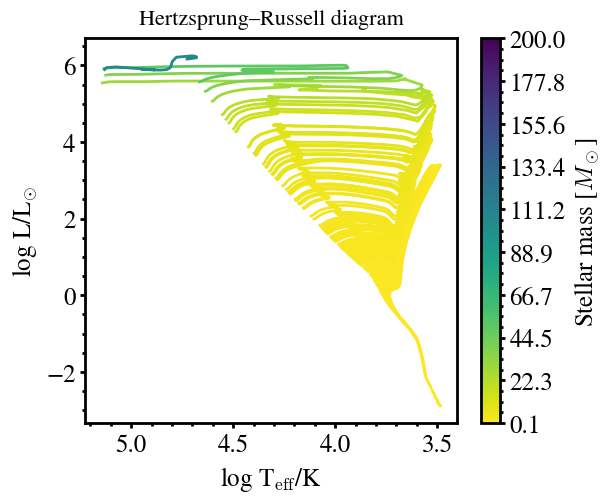

In [10]:
# Logarithmic color normalization for stellar mass
##norm = mpl.colors.LogNorm(vmin=min_m, vmax=max_m)
##cmap = mpl.cm.ScalarMappable(norm=norm, cmap='viridis_r')
##cmap.set_array([])

# Linear normalization for colorbar
norm = mpl.colors.Normalize(vmin=0.0, vmax=max_m)
cmap = mpl.cm.ScalarMappable(norm=norm, cmap='viridis_r')
cmap.set_array([])

# --- Read all .dat track files ---
base_name = os.path.join(run_dir, 'output')
file_name = glob.glob(base_name + "/*.dat")
file_name.sort()

fig, ax = plt.subplots(figsize=(6,5))
phase_lim = 5                # Limit the phases for clarity

i=0

# --- Plot each track ---
for eachfile in file_name:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

    i = i+1

    # Plot track with color determined by mass
    ax.plot(Teff, L, color=cmap.to_rgba(m))

print('i',i)

# --- Add colorbar for stellar mass ---
cbar = plt.colorbar(cmap, ax=ax)
cbar.set_label(r'Stellar mass [$M_\odot$]')
##ticks = [10,20,30,40,60, 100]
##cbar.set_ticks(ticks)
##cbar.set_ticklabels([str(t) for t in ticks])
ticks = np.linspace(min_m, max_m, 10)  
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.1f}" for t in ticks]) 
cbar.update_ticks()

ax.set_xlabel(r'log T$_{\mathrm{eff}}$/K')
ax.set_ylabel(r'log L/L$_{\odot}$')
ax.invert_xaxis()
ax.set_title("Hertzsprung–Russell diagram")

# Maximum Stellar Radius

In the HR diagram above, we followed the full evolutionary track of a single star, showing how its temperature and luminosity change over time.
A key outcome of that evolution is the star’s changing radius — as it expands off the main sequence, it may fill its Roche lobe in a binary system.
By plotting the maximum stellar radius against initial mass for many such tracks, we can identify which stars are likely to undergo binary interaction.
The following script plots the maximum stellar radius reached during the evolution of stars of different initial masses, color-coded by evolutionary phase.



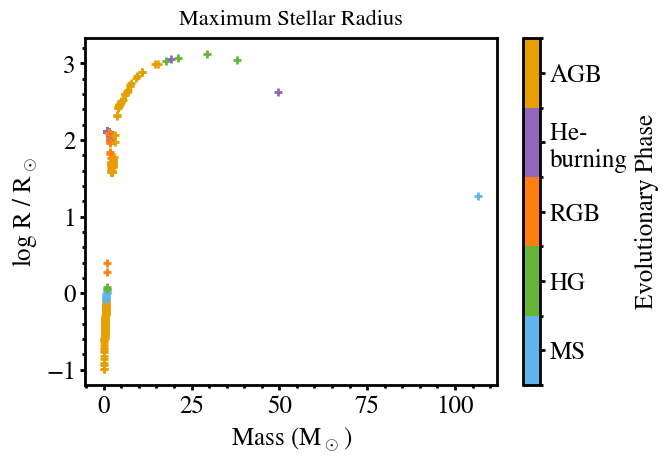

In [11]:
def plot_max_rad(ax, name, i=0):
    """
    Plot the maximum stellar radius as a function of initial mass.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The plot axis on which to draw the scatter points.
    name : str
        Directory under run_dir containing evolution track files (*.dat).
    i : int, optional
        Marker style index (default: 0). Allows differentiating model sets.
    """

    base_dir = os.path.join(run_dir, name)
    file_names = glob.glob(base_dir + "/*.dat")
    file_names.sort()

    for eachfile in file_names:
        # Extract the initial mass from the filename (e.g. "00500" → 5.00 M_sun)
        mass = re.findall(r"[0-9]{5}", eachfile)[0]
        m = float(mass) / 100.0

        # Read the stellar evolution track
        evolve_data = pd.read_table(eachfile, sep=r"\s+")

        # Find maximum stellar radius (in log R/Rsun)
        R = max(evolve_data['log_radius'])

        # Identify the evolutionary phase where max radius occurs
        p = evolve_data['phase'].iloc[np.argmax(evolve_data['log_radius'])]

        # Plot as a colored scatter point (color encodes phase)
        ax.scatter(m, R, marker=markerlist[i], c=phase_colors[p-1])

    return



def add_phase_colorbar(ax, colors, labels):
    """
    Add a colorbar to represent evolutionary phases.
    """

    cmap = mpl.colors.ListedColormap(colors)
    norm = mpl.colors.BoundaryNorm(range(len(labels) + 1), cmap.N)

    cbar = plt.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
        ax=ax,
        ticks=np.arange(len(labels)) + 0.5,
    )
    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Evolutionary Phase")
    return cbar


# ---------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------
markerlist = ['+', '.', '*']

# Colors for different evolutionary phases (e.g., MS, RGB, HeB, etc.)
phase_colors = [
    "#61b3ed",  # MS
    "#66B436",  # Hertzsprung gap
    '#ff7f0e',  # RGB
    '#9467bd',  # He-burning
    '#E69F00',  # AGB
]

fig, ax = plt.subplots()

# Replace with your working directory path before running
# run_dir = "/path/to/METISSE_runs"

# Call the function to plot all stars in the given directory
plot_max_rad(ax, 'output')

ax.set_xlabel(r'Mass (M$_\odot$)')
ax.set_ylabel(r'log R / R$_\odot$')
ax.set_title('Maximum Stellar Radius')


phase_labels = [
    "MS", "HG", "RGB",
    "He- \nburning", "AGB"
]

# Add the phase colorbar
add_phase_colorbar(ax,phase_colors,phase_labels)

# Remnant Mass vs Initial Stellar Mass

Having explored how the maximum stellar radius varies across different stellar models,
we can now turn to the endpoints of stellar evolution — the compact remnants.
By plotting the final (remnant) mass as a function of the initial ZAMS mass,
we can compare how different model grids (MESA, MIST, BOOST) predict the formation
of neutron stars and black holes. This provides direct insight into how
differences in stellar evolution physics influence the compact object mass spectrum.

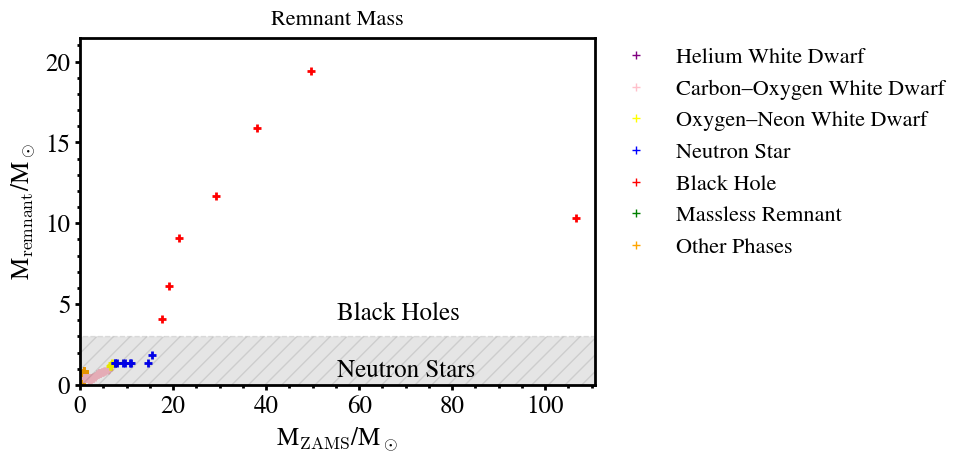

In [12]:

#base_dir = os.path.join(run_dir, name)
base_dir = os.path.join(run_dir, 'output')
file_names = glob.glob(base_dir + "/*.dat")
file_names.sort()

fig, ax = plt.subplots()

max_end_mass = 0
max_ini_mass = 0
phase_colors = {
    10: 'purple',
    11: 'pink',
    12: 'yellow',
    13: 'blue',
    14: 'red',
    15: 'green'
}

default_color = 'orange'


for eachfile in file_names:
    # Read evolution track (tabular text file)
    evolve_data = pd.read_table(eachfile, sep=r"\s+")

    # Initial stellar mass (first row of the track)
    mass = evolve_data['mass'].iloc[0]

    # Final mass after evolution (last row of the track)
    end_mass = evolve_data['mass'].iloc[-1]

    ## Final phase
    final_phase = evolve_data['phase'].iloc[-1]

    # update maximum end mass
    if end_mass > max_end_mass:
        max_end_mass = end_mass+2

     # update maximum initial mass
    if mass > max_ini_mass:
        max_ini_mass = mass+2
    

    final_phase = int(evolve_data['phase'].iloc[-1])

    color = phase_colors.get(final_phase, default_color)
    
    ax.scatter(mass, end_mass, color=color, marker='+')

    # Plot a single point: (initial mass, remnant mass)
    # ax.scatter(mass, end_mass, color='red',marker='+')






legend_elements = [
    Line2D([0], [0], marker='+', color='purple',  linestyle='None', label='Helium White Dwarf'),
    Line2D([0], [0], marker='+', color='pink',  linestyle='None', label='Carbon–Oxygen White Dwarf'),
    Line2D([0], [0], marker='+', color='yellow',  linestyle='None', label='Oxygen–Neon White Dwarf'),
    Line2D([0], [0], marker='+', color='blue',  linestyle='None', label='Neutron Star'),
    Line2D([0], [0], marker='+', color='red', linestyle='None', label='Black Hole'),
    Line2D([0], [0], marker='+', color='green',  linestyle='None', label='Massless Remnant'),    
    Line2D([0], [0], marker='+', color='orange',   linestyle='None', label='Other Phases')
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),   # pushes legend outside
    borderaxespad=0,
    frameon=False
)

if max_end_mass<4.5:
    y_max = 4.5
else :
    y_max = max_end_mass

x_max = max_ini_mass +2
half_x_max = x_max/2

ax.set_xlabel(r'M$_{\rm ZAMS}$/M$_\odot$')         # initial (ZAMS) mass
ax.set_ylabel(r'M$_{\rm remnant}$/M$_\odot$')      # final remnant mass
ax.set_ylim(ymin=0.0, ymax=y_max)
ax.set_xlim(xmin=0.0, xmax=x_max)

# Annotate physical regions for neutron stars and black holes
ax.text(half_x_max , 0.5, 'Neutron Stars')
ax.text(half_x_max , 4.0, 'Black Holes')
plt.fill_between([0, x_max], 3, hatch="//", ls='--', alpha=0.1, color='k')

ax.set_title('Remnant Mass') 

plt.savefig("rem_mass.png", dpi=300, bbox_inches='tight')  